# Backend Benchmark: PyTorch vs TensorRT

Notebook nay benchmark accuracy + latency cho tat ca checkpoint trong `model/` ma khong can goi API endpoint.


In [1]:
from __future__ import annotations

import json
import os
import random
import sys
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

import torch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "app").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from app.services.device import choose_device
from app.services.model_loader import load_checkpoint, build_runtime_from_ckpt
from app.services.preprocessing import preprocess_pil
from app.services.predictor import predict_one


d:\App\anaconda3\envs\pt_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ====== User Config ======
MODELS_ROOT = Path(r"D:\Homework\BackEnd\ModelDetectApi\model")
DATA_ROOT = Path(r"D:\Homework\NC\data\dataset\bigplantsDataset-resize")

DEVICE_STR = "cuda:0"
BACKENDS = ["pytorch", "tensorrt"]
TWO_PASS = True
TOPK = 1

MAX_IMAGES_PER_CLASS = 100  # None -> dung toan bo
WARMUP_IMAGES = 30
SEED = 42

TRT_FP16 = True
TRT_STRICT = True
TRT_WORKSPACE_GB = 4
TRT_DEVICE_ID = 0

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(r"D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs") / timestamp
ARTIFACTS_DIR = OUT_DIR / "artifacts"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"OUT_DIR: {OUT_DIR}")
print(f"DEVICE_STR: {DEVICE_STR}")


OUT_DIR: D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs\20260423_061847
DEVICE_STR: cuda:0


In [3]:
SCRIPT_BY_DIR = {
    "mobilenetv3large-deeplabv3": "mobilenetv3large-deeplabv3",
    "mobilenetv3large-mask2former": "mobilenetv3large-mask2former",
    "mobilenetv3large-segformer": "mobilenetv3large-segformer",
    "resnet50-deeplabv3": "resnet50-deeplabv3",
    "resnet50-mask2former": "resnet50-mask2former",
    "resnet50-segformer": "resnet50-segformer",
}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def discover_checkpoints(models_root: Path) -> pd.DataFrame:
    rows: List[Dict] = []
    for ckpt in sorted(models_root.rglob("*.pt")):
        try:
            rel = ckpt.relative_to(models_root)
        except Exception:
            continue
        if len(rel.parts) < 2:
            continue
        model_dir = rel.parts[0]
        if model_dir not in SCRIPT_BY_DIR:
            continue
        rows.append({
            "model_script": SCRIPT_BY_DIR[model_dir],
            "model_dir": model_dir,
            "ckpt_name": ckpt.name,
            "ckpt_stem": ckpt.stem,
            "ckpt_path": str(ckpt),
        })
    df = pd.DataFrame(rows).sort_values(["model_script", "ckpt_name"]).reset_index(drop=True)
    return df


def build_image_index(data_root: Path, max_images_per_class: int | None, seed: int = 42) -> pd.DataFrame:
    rng = random.Random(seed)
    rows: List[Dict] = []

    for species_dir in sorted([p for p in data_root.iterdir() if p.is_dir()]):
        species = species_dir.name
        images = [p for p in species_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]
        images = sorted(set(images))
        if max_images_per_class is not None and len(images) > max_images_per_class:
            rng.shuffle(images)
            images = images[:max_images_per_class]

        for p in images:
            rows.append({"img_path": str(p), "true_label": species})

    return pd.DataFrame(rows)


@dataclass
class RuntimeBundle:
    model: object
    class_names: List[str]
    meta: Dict
    device: torch.device


def load_runtime_for_case(
    ckpt_path: Path,
    model_script: str,
    backend: str,
    device: torch.device,
    artifacts_dir: Path,
) -> RuntimeBundle:
    ckpt = load_checkpoint(str(ckpt_path))
    case_dir = artifacts_dir / model_script / ckpt_path.stem / backend
    case_dir.mkdir(parents=True, exist_ok=True)

    onnx_path = case_dir / f"{ckpt_path.stem}.onnx"
    trt_cache_dir = case_dir / f"{ckpt_path.stem}_trt_cache"
    trt_cache_dir.mkdir(parents=True, exist_ok=True)

    model, class_names, meta = build_runtime_from_ckpt(
        ckpt=ckpt,
        device=device,
        model_script=model_script,
        infer_backend=backend,
        onnx_path=str(onnx_path),
        trt_engine_cache_dir=str(trt_cache_dir),
        trt_fp16=TRT_FP16,
        trt_strict=TRT_STRICT,
        trt_workspace_gb=TRT_WORKSPACE_GB,
        trt_device_id=TRT_DEVICE_ID,
    )
    return RuntimeBundle(model=model, class_names=class_names, meta=meta, device=device)


In [4]:
df_ckpt = discover_checkpoints(MODELS_ROOT)
if df_ckpt.empty:
    raise RuntimeError(f"Khong tim thay checkpoint nao trong: {MODELS_ROOT}")

df_images = build_image_index(DATA_ROOT, max_images_per_class=MAX_IMAGES_PER_CLASS, seed=SEED)
if df_images.empty:
    raise RuntimeError(f"Khong tim thay anh nao trong: {DATA_ROOT}")

print(f"Checkpoints found: {len(df_ckpt)}")
display(df_ckpt)
print(f"Indexed images: {len(df_images)}")
print(f"Classes in dataset: {df_images['true_label'].nunique()}")


Checkpoints found: 12


,model_script,model_dir,ckpt_name,ckpt_stem,ckpt_path
0,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-384x384.pt,mobilenetv3large-deeplabv3-384x384,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
1,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-512x512.pt,mobilenetv3large-deeplabv3-512x512,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
2,mobilenetv3large-mask2former,mobilenetv3large-mask2former,mobilenetv3large-mask2former-384x384.pt,mobilenetv3large-mask2former-384x384,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
3,mobilenetv3large-mask2former,mobilenetv3large-mask2former,mobilenetv3large-mask2former-512x512.pt,mobilenetv3large-mask2former-512x512,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
4,mobilenetv3large-segformer,mobilenetv3large-segformer,mobilenetv3large-segformerb4-384x384.pt,mobilenetv3large-segformerb4-384x384,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
5,mobilenetv3large-segformer,mobilenetv3large-segformer,mobilenetv3large-segformerb4-512x512.pt,mobilenetv3large-segformerb4-512x512,D:\Homework\BackEnd\ModelDetectApi\model\mobil...
6,resnet50-deeplabv3,resnet50-deeplabv3,resnet50-deeplabv3-384x384.pt,resnet50-deeplabv3-384x384,D:\Homework\BackEnd\ModelDetectApi\model\resne...
7,resnet50-deeplabv3,resnet50-deeplabv3,resnet50-deeplabv3-512x512.pt,resnet50-deeplabv3-512x512,D:\Homework\BackEnd\ModelDetectApi\model\resne...
8,resnet50-mask2former,resnet50-mask2former,resnet50-mask2former-384x384.pt,resnet50-mask2former-384x384,D:\Homework\BackEnd\ModelDetectApi\model\resne...
9,resnet50-mask2former,resnet50-mask2former,resnet50-mask2former-512x512.pt,resnet50-mask2former-512x512,D:\Homework\BackEnd\ModelDetectApi\model\resne...


Indexed images: 10000
Classes in dataset: 100


In [5]:
def measure_one(model_bundle: RuntimeBundle, img_path: str, true_label: str, topk: int = 1, two_pass: bool = True) -> Dict:
    img = Image.open(img_path).convert("RGB")
    preprocess_mode = str(model_bundle.meta.get("preprocess_mode", "imagenet_norm"))

    t0 = time.perf_counter()
    x = preprocess_pil(img, device=model_bundle.device, mode=preprocess_mode)
    t1 = time.perf_counter()

    out = predict_one(
        model_bundle.model,
        x,
        model_bundle.class_names,
        organ_dim=int(model_bundle.meta.get("organ_dim", 1)),
        topk=topk,
        two_pass=two_pass,
    )

    t2 = time.perf_counter()

    pred_label = out["pred"]["label"]
    return {
        "true_label": true_label,
        "pred_label": pred_label,
        "correct": int(pred_label == true_label),
        "preprocess_ms": (t1 - t0) * 1000.0,
        "inference_ms": float(out["timing_ms"]["inference_ms"]),
        "total_ms": (t2 - t0) * 1000.0,
    }


def summarize_latency(values: List[float]) -> Dict[str, float]:
    if not values:
        return {
            "mean": float("nan"),
            "p50": float("nan"),
            "p90": float("nan"),
            "p95": float("nan"),
        }
    arr = np.asarray(values, dtype=np.float64)
    return {
        "mean": float(np.mean(arr)),
        "p50": float(np.percentile(arr, 50)),
        "p90": float(np.percentile(arr, 90)),
        "p95": float(np.percentile(arr, 95)),
    }


In [ ]:
device = choose_device(DEVICE_STR)
print(f"Device chosen: {device}")

raw_records: List[Dict] = []
summary_records: List[Dict] = []

for _, row in tqdm(df_ckpt.iterrows(), total=len(df_ckpt), desc="Checkpoint"):
    model_script = str(row["model_script"])
    ckpt_name = str(row["ckpt_name"])
    ckpt_stem = str(row["ckpt_stem"])
    ckpt_path = Path(str(row["ckpt_path"]))

    for backend in BACKENDS:
        run_id = f"{model_script}|{ckpt_name}|{backend}"
        print(f"\n[RUN] {run_id}")

        startup_t0 = time.perf_counter()
        try:
            bundle = load_runtime_for_case(
                ckpt_path=ckpt_path,
                model_script=model_script,
                backend=backend,
                device=device,
                artifacts_dir=ARTIFACTS_DIR,
            )
            startup_t1 = time.perf_counter()
        except Exception as exc:
            startup_t1 = time.perf_counter()
            summary_records.append({
                "run_id": run_id,
                "model_script": model_script,
                "ckpt_name": ckpt_name,
                "ckpt_stem": ckpt_stem,
                "backend": backend,
                "status": "failed",
                "error": str(exc),
                "startup_ms": (startup_t1 - startup_t0) * 1000.0,
            })
            print(f"  -> FAILED: {exc}")
            continue

        class_set = set(bundle.class_names)
        df_eval = df_images[df_images["true_label"].isin(class_set)].reset_index(drop=True)
        if df_eval.empty:
            summary_records.append({
                "run_id": run_id,
                "model_script": model_script,
                "ckpt_name": ckpt_name,
                "ckpt_stem": ckpt_stem,
                "backend": backend,
                "status": "failed",
                "error": "No evaluable images (labels mismatch)",
                "startup_ms": (startup_t1 - startup_t0) * 1000.0,
            })
            print("  -> FAILED: No evaluable images")
            continue

        first_row = df_eval.iloc[0]
        first_rec = measure_one(
            model_bundle=bundle,
            img_path=str(first_row["img_path"]),
            true_label=str(first_row["true_label"]),
            topk=TOPK,
            two_pass=TWO_PASS,
        )

        warmup_end = min(1 + WARMUP_IMAGES, len(df_eval))
        for idx in range(1, warmup_end):
            w = df_eval.iloc[idx]
            _ = measure_one(
                model_bundle=bundle,
                img_path=str(w["img_path"]),
                true_label=str(w["true_label"]),
                topk=TOPK,
                two_pass=TWO_PASS,
            )

        eval_records: List[Dict] = []
        for idx in tqdm(range(warmup_end, len(df_eval)), desc=f"Eval {backend}", leave=False):
            rr = df_eval.iloc[idx]
            rec = measure_one(
                model_bundle=bundle,
                img_path=str(rr["img_path"]),
                true_label=str(rr["true_label"]),
                topk=TOPK,
                two_pass=TWO_PASS,
            )
            rec.update({
                "run_id": run_id,
                "model_script": model_script,
                "ckpt_name": ckpt_name,
                "ckpt_stem": ckpt_stem,
                "backend": backend,
                "img_path": str(rr["img_path"]),
            })
            eval_records.append(rec)

        raw_records.extend(eval_records)

        acc = float(np.mean([r["correct"] for r in eval_records])) if eval_records else float("nan")
        infer_stats = summarize_latency([r["inference_ms"] for r in eval_records])
        total_stats = summarize_latency([r["total_ms"] for r in eval_records])
        pre_stats = summarize_latency([r["preprocess_ms"] for r in eval_records])

        summary_records.append({
            "run_id": run_id,
            "model_script": model_script,
            "ckpt_name": ckpt_name,
            "ckpt_stem": ckpt_stem,
            "backend": backend,
            "status": "ok",
            "num_eval_images": int(len(eval_records)),
            "startup_ms": (startup_t1 - startup_t0) * 1000.0,
            "first_infer_ms": float(first_rec["inference_ms"]),
            "accuracy_top1": acc,
            "infer_mean_ms": infer_stats["mean"],
            "infer_p50_ms": infer_stats["p50"],
            "infer_p90_ms": infer_stats["p90"],
            "infer_p95_ms": infer_stats["p95"],
            "total_mean_ms": total_stats["mean"],
            "total_p95_ms": total_stats["p95"],
            "preprocess_mean_ms": pre_stats["mean"],
        })

        print(
            f"  -> OK: acc={acc:.4f}, infer_mean={infer_stats['mean']:.2f}ms, infer_p95={infer_stats['p95']:.2f}ms, startup={((startup_t1-startup_t0)*1000.0):.2f}ms"
        )

Device chosen: cuda:0
Device chosen: cuda:0
Checkpoint:   0%|          | 0/12 [00:00<?, ?it/s]

[RUN] mobilenetv3large-deeplabv3|mobilenetv3large-deeplabv3-384x384.pt|pytorch
  -> OK: acc=0.8740, infer_mean=36.34ms, infer_p95=47.61ms, startup=6226.15ms

[RUN] mobilenetv3large-deeplabv3|mobilenetv3large-deeplabv3-384x384.pt|tensorrt
  -> OK: acc=0.8738, infer_mean=33.31ms, infer_p95=42.37ms, startup=10312.83ms
Checkpoint:   8%|█         | 1/12 [0:20:06<3:48:37, 1206.31s/it]


[RUN] mobilenetv3large-deeplabv3|mobilenetv3large-deeplabv3-512x512.pt|pytorch
  -> OK: acc=0.8910, infer_mean=40.07ms, infer_p95=59.48ms, startup=6898.99ms

[RUN] mobilenetv3large-deeplabv3|mobilenetv3large-deeplabv3-512x512.pt|tensorrt
  -> OK: acc=0.8908, infer_mean=33.93ms, infer_p95=42.79ms, startup=12620.99ms
Checkpoint:  17%|█         | 2/12 [0:36:33<3:15:11, 1096.54s/it]


[RUN] mobilenetv3large-mask2former|mobilenetv3large-mask2former-384x384.pt|pytorch
  -> OK: acc=0.8720, infer_mean=39.25ms, infer_p95=51

In [8]:
df_raw = pd.DataFrame(raw_records)
df_summary = pd.DataFrame(summary_records)

raw_csv = OUT_DIR / "benchmark_raw_per_image.csv"
summary_csv = OUT_DIR / "benchmark_summary.csv"
summary_json = OUT_DIR / "benchmark_summary.json"

if not df_raw.empty:
    df_raw.to_csv(raw_csv, index=False, encoding="utf-8")
df_summary.to_csv(summary_csv, index=False, encoding="utf-8")
summary_json.write_text(df_summary.to_json(orient="records", indent=2), encoding="utf-8")

print(f"Saved: {summary_csv}")
if raw_csv.exists():
    print(f"Saved: {raw_csv}")
print(f"Saved: {summary_json}")
display(df_summary.sort_values(["model_script", "ckpt_name", "backend"]).reset_index(drop=True))


Saved: D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs\20260423_061847\benchmark_summary.csv
Saved: D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs\20260423_061847\benchmark_summary.json


,run_id,model_script,ckpt_name,ckpt_stem,backend,status,num_eval_images,startup_ms,first_infer_ms,accuracy_top1,infer_mean_ms,infer_p50_ms,infer_p90_ms,infer_p95_ms,total_mean_ms,total_p95_ms,preprocess_mean_ms
0,mobilenetv3large-deeplabv3|mobilenetv3large-de...,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-384x384.pt,mobilenetv3large-deeplabv3-384x384,pytorch,ok,13094,6226.15,39.25,0.8740,36.34,34.16,43.80,47.61,42.84,54.44,6.5
1,mobilenetv3large-deeplabv3|mobilenetv3large-de...,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-384x384.pt,mobilenetv3large-deeplabv3-384x384,tensorrt,ok,13094,10312.83,35.97,0.8738,33.31,31.31,38.98,42.37,39.81,49.20,6.5
2,mobilenetv3large-deeplabv3|mobilenetv3large-de...,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-512x512.pt,mobilenetv3large-deeplabv3-512x512,pytorch,ok,13094,6898.99,43.28,0.8910,40.07,37.67,54.72,59.48,48.27,68.09,8.2
3,mobilenetv3large-deeplabv3|mobilenetv3large-de...,mobilenetv3large-deeplabv3,mobilenetv3large-deeplabv3-512x512.pt,mobilenetv3large-deeplabv3-512x512,tensorrt,ok,13094,12620.99,36.64,0.8908,33.93,31.89,39.37,42.79,42.13,51.40,8.2
4,mobilenetv3large-mask2former|mobilenetv3large-...,mobilenetv3large-mask2former,mobilenetv3large-mask2former-384x384.pt,mobilenetv3large-mask2former-384x384,pytorch,ok,13094,6350.67,42.39,0.8720,39.25,36.89,47.31,51.42,46.65,59.19,7.4
5,mobilenetv3large-mask2former|mobilenetv3large-...,mobilenetv3large-mask2former,mobilenetv3large-mask2former-384x384.pt,mobilenetv3large-mask2former-384x384,tensorrt,ok,13094,10519.09,38.85,0.8712,35.97,33.81,42.10,45.76,43.37,53.53,7.4
6,mobilenetv3large-mask2former|mobilenetv3large-...,mobilenetv3large-mask2former,mobilenetv3large-mask2former-512x512.pt,mobilenetv3large-mask2former-512x512,pytorch,ok,13094,7036.97,46.74,0.8890,43.28,40.68,59.10,64.24,52.38,73.79,9.1
7,mobilenetv3large-mask2former|mobilenetv3large-...,mobilenetv3large-mask2former,mobilenetv3large-mask2former-512x512.pt,mobilenetv3large-mask2former-512x512,tensorrt,ok,13094,12873.41,39.57,0.8882,36.64,34.44,42.51,46.21,45.74,55.77,9.1
8,mobilenetv3large-segformer|mobilenetv3large-se...,mobilenetv3large-segformer,mobilenetv3large-segformerb4-384x384.pt,mobilenetv3large-segformerb4-384x384,pytorch,ok,13094,6226.15,40.81,0.8760,37.79,35.52,45.55,49.51,44.29,56.34,6.5
9,mobilenetv3large-segformer|mobilenetv3large-se...,mobilenetv3large-segformer,mobilenetv3large-segformerb4-384x384.pt,mobilenetv3large-segformerb4-384x384,tensorrt,ok,13094,10312.83,37.41,0.8757,34.64,32.56,40.54,44.06,41.14,50.89,6.5


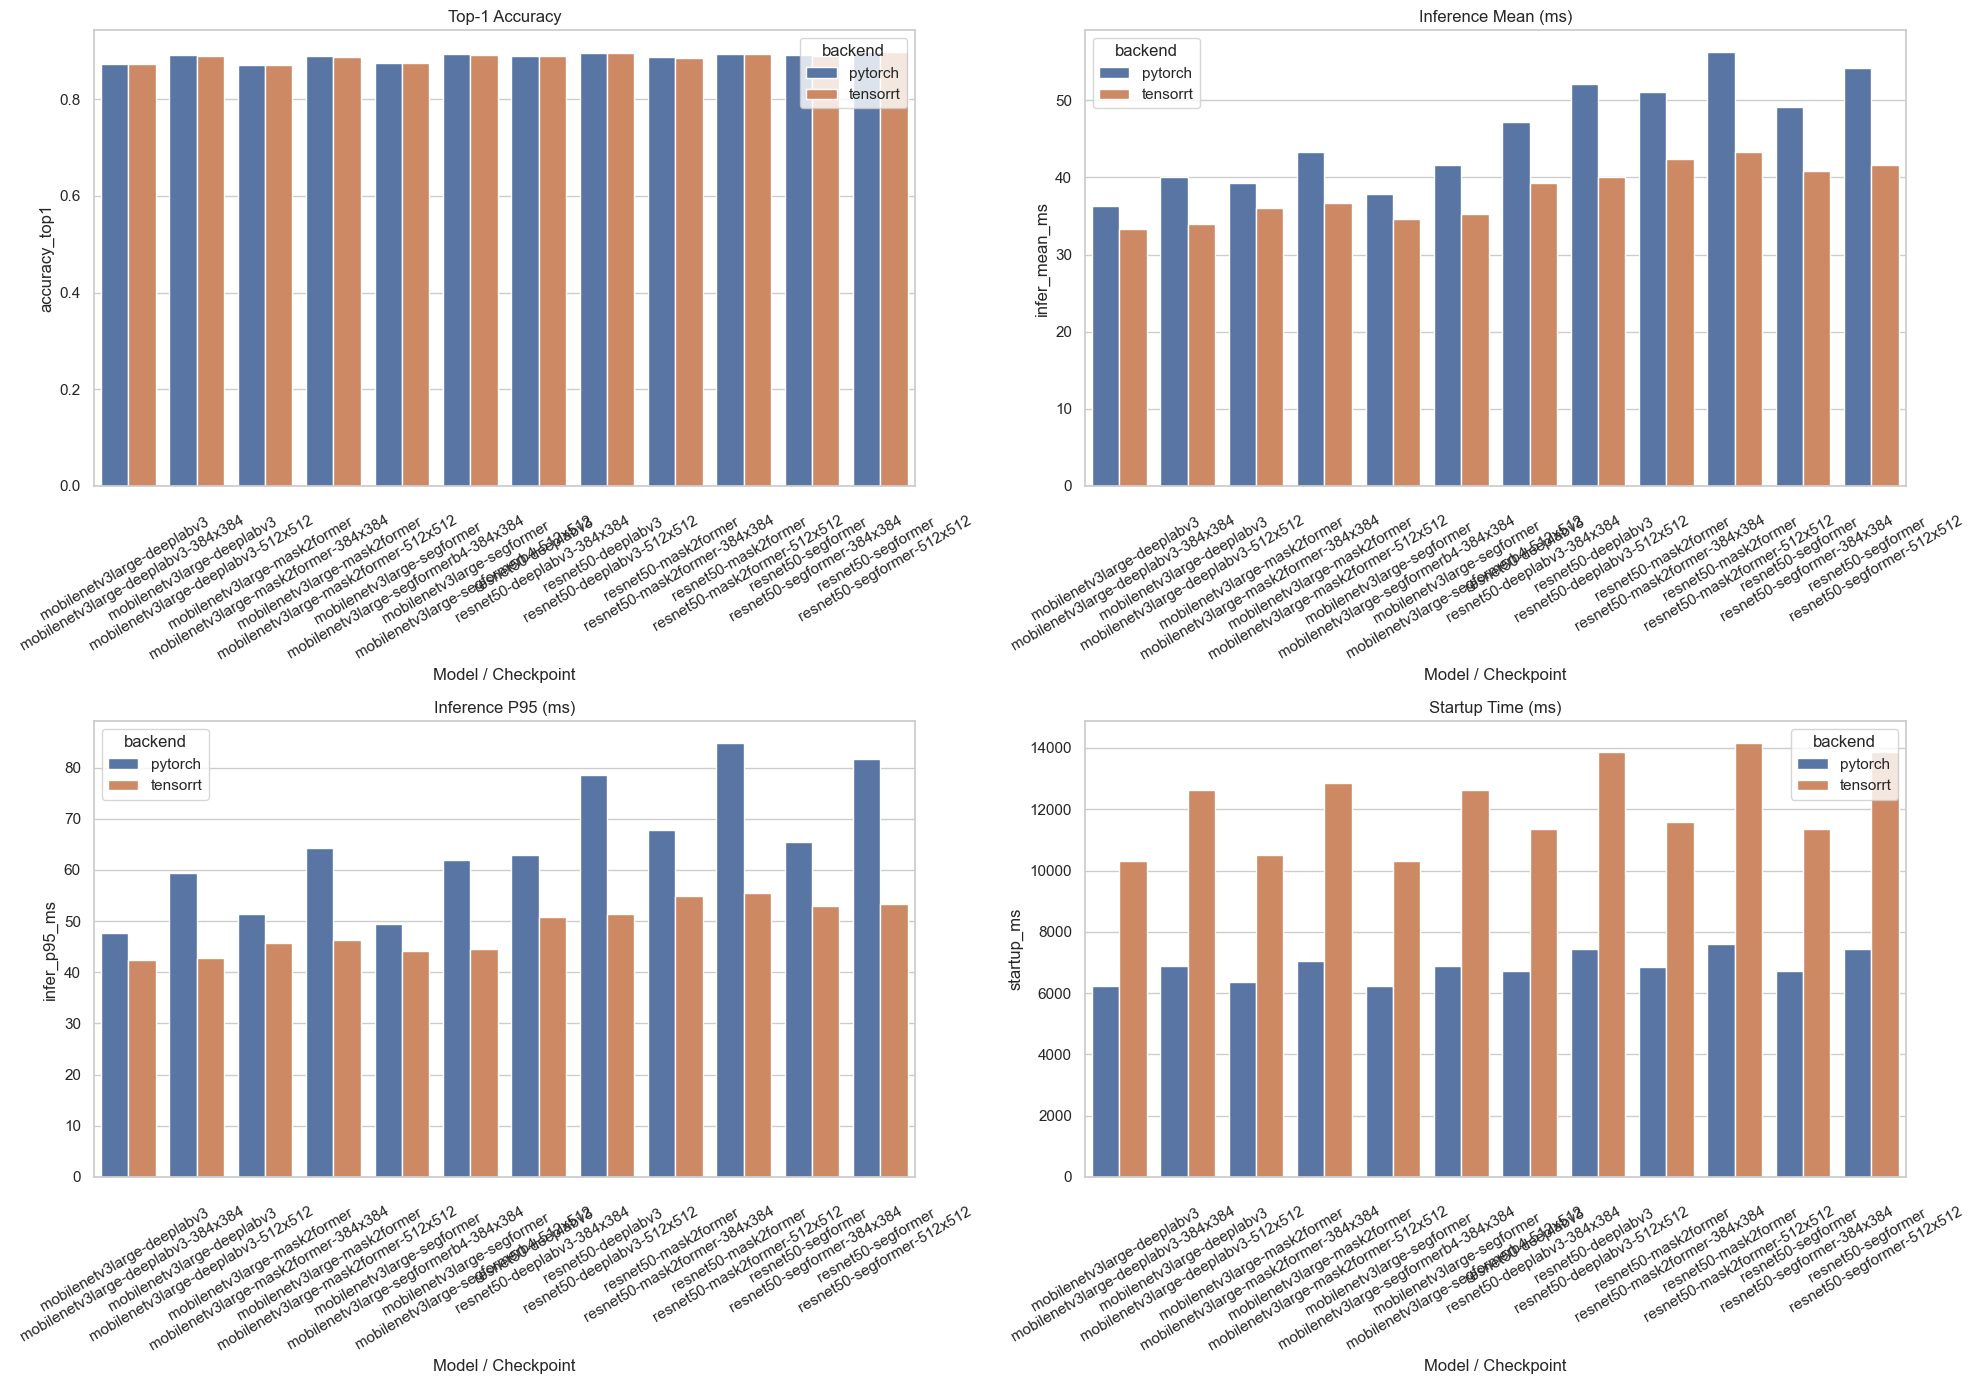

Saved: D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs\20260423_061847\benchmark_charts.png


In [9]:
df_ok = df_summary[df_summary["status"] == "ok"].copy()
if df_ok.empty:
    raise RuntimeError("Khong co run nao thanh cong de ve chart")

df_ok["case"] = df_ok["model_script"] + "\n" + df_ok["ckpt_stem"]

if HAS_SEABORN:
    sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for ax, metric, title in [
    (axes[0, 0], "accuracy_top1", "Top-1 Accuracy"),
    (axes[0, 1], "infer_mean_ms", "Inference Mean (ms)"),
    (axes[1, 0], "infer_p95_ms", "Inference P95 (ms)"),
    (axes[1, 1], "startup_ms", "Startup Time (ms)"),
]:
    if HAS_SEABORN:
        sns.barplot(data=df_ok, x="case", y=metric, hue="backend", ax=ax)
    else:
        pivot = df_ok.pivot_table(index="case", columns="backend", values=metric, aggfunc="mean")
        pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Model / Checkpoint")
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
chart_path = OUT_DIR / "benchmark_charts.png"
plt.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {chart_path}")


In [10]:
# Bieu do chenhlech TensorRT vs PyTorch theo moi checkpoint (accuracy va p95)
df_cmp = df_ok.pivot_table(
    index=["model_script", "ckpt_name", "ckpt_stem"],
    columns="backend",
    values=["accuracy_top1", "infer_p95_ms"],
    aggfunc="mean",
)

if ("accuracy_top1", "tensorrt") in df_cmp.columns and ("accuracy_top1", "pytorch") in df_cmp.columns:
    df_cmp[("delta_accuracy_trt_minus_torch", "")] = df_cmp[("accuracy_top1", "tensorrt")] - df_cmp[("accuracy_top1", "pytorch")]
if ("infer_p95_ms", "tensorrt") in df_cmp.columns and ("infer_p95_ms", "pytorch") in df_cmp.columns:
    df_cmp[("speedup_p95_torch_div_trt", "")] = df_cmp[("infer_p95_ms", "pytorch")] / df_cmp[("infer_p95_ms", "tensorrt")]

df_cmp = df_cmp.reset_index()
cmp_csv = OUT_DIR / "benchmark_compare_trt_vs_torch.csv"
df_cmp.to_csv(cmp_csv, index=False, encoding="utf-8")
print(f"Saved: {cmp_csv}")
display(df_cmp)


Saved: D:\Homework\BackEnd\ModelDetectApi\benchmark_outputs\20260423_061847\benchmark_compare_trt_vs_torch.csv


model_script  \
backend                                 
0          mobilenetv3large-deeplabv3   
1          mobilenetv3large-deeplabv3   
2        mobilenetv3large-mask2former   
3        mobilenetv3large-mask2former   
4          mobilenetv3large-segformer   
5          mobilenetv3large-segformer   
6                  resnet50-deeplabv3   
7                  resnet50-deeplabv3   
8                resnet50-mask2former   
9                resnet50-mask2former   
10                 resnet50-segformer   
11                 resnet50-segformer   

                                       ckpt_name  \
backend                                            
0          mobilenetv3large-deeplabv3-384x384.pt   
1          mobilenetv3large-deeplabv3-512x512.pt   
2        mobilenetv3large-mask2former-384x384.pt   
3        mobilenetv3large-mask2former-512x512.pt   
4        mobilenetv3large-segformerb4-384x384.pt   
5        mobilenetv3large-segformerb4-512x512.pt   
6                  resnet50-deeplabv3-384x384.pt   
7                  resnet50-deeplabv3-512x512.pt   
8                resnet50-mask2former-384x384.pt   
9                resnet50-mask2former-512x512.pt   
10                 resnet50-segformer-384x384.pt   
11                 resnet50-segformer-512x512.pt   

                                    ckpt_stem accuracy_top1           \
backend                                             pytorch tensorrt   
0          mobilenetv3large-deeplabv3-384x384         0.874   0.8738   
1          mobilenetv3large-deeplabv3-512x512         0.891   0.8908   
2        mobilenetv3large-mask2former-384x384         0.872   0.8712   
3        mobilenetv3large-mask2former-512x512         0.889   0.8882   
4        mobilenetv3large-segformerb4-384x384         0.876   0.8757   
5        mobilenetv3large-segformerb4-512x512         0.893   0.8927   
6                  resnet50-deeplabv3-384x384         0.889   0.8888   
7                  resnet50-deeplabv3-512x512         0.896   0.8958   
8                resnet50-mask2former-384x384         0.887   0.8862   
9                resnet50-mask2former-512x512         0.894   0.8932   
10                 resnet50-segformer-384x384         0.891   0.8907   
11                 resnet50-segformer-512x512         0.898   0.8977   

        infer_p95_ms          delta_accuracy_trt_minus_torch  \
backend      pytorch tensorrt                                  
0              47.61    42.37                        -0.0002   
1              59.48    42.79                        -0.0002   
2              51.42    45.76                        -0.0008   
3              64.24    46.21                        -0.0008   
4              49.51    44.06                        -0.0003   
5              61.86    44.50                        -0.0003   
6              62.85    50.84                        -0.0002   
7              78.51    51.35                        -0.0002   
8              67.88    54.91                        -0.0008   
9              84.79    55.46                        -0.0008   
10             65.36    52.87                        -0.0003   
11             81.65    53.40                        -0.0003   

        speedup_p95_torch_div_trt  
backend                            
0                        1.123672  
1                        1.390044  
2                        1.123689  
3                        1.390175  
4                        1.123695  
5                        1.390112  
6                        1.236231  
7                        1.528919  
8                        1.236205  
9                        1.528850  
10                       1.236240  
11                       1.529026